# Tarea 3.3.1: Feature Engineering - Métricas Derivadas Biométricas

## Objetivo

Calcular y analizar las tres métricas derivadas esenciales para el sistema de Bio-Adaptabilidad:

1. **`ln_rmssd`**: Transformación logarítmica de HRV para normalización estadística
2. **`hrv_baseline_7d`**: Media Móvil Exponencial (EMA) de 7 días para establecer línea base personal
3. **`sleep_consistency`**: Desviación estándar de la hora de dormir (ventana 7 días) para medir regularidad circadiana

---

## Estructura del Análisis

### Parte 1: Transformación Logarítmica HRV (ln_rmssd)
- Carga y exploración inicial de datos
- Análisis de distribución original (`hrv_rmssd`)
- Aplicación de transformación logarítmica
- Comparación de distribuciones (antes/después)
- Pruebas de normalidad
- Visualizaciones comparativas

### Parte 2: Baseline HRV con Media Móvil Exponencial (hrv_baseline_7d)
- Concepto de EMA y por qué es mejor que media simple
- Cálculo de EMA con span=7 días
- Visualización de baseline vs valores diarios
- Interpretación de desviaciones del baseline

### Parte 3: Consistencia del Sueño (sleep_consistency)
- Extracción de hora de dormir desde `sleep_start_time`
- Cálculo de desviación estándar en ventana móvil de 7 días
- Visualización de regularidad circadiana
- Correlación con calidad de sueño

## 1. Importación de Librerías

In [16]:
import json
from pathlib import Path
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import normaltest, shapiro, jarque_bera

# Configuración de estilo para visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configuración de pandas para mostrar más columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 2. Carga de Datos

In [17]:
# Ruta al archivo JSON con datos de Suunto
data_path = Path("../data/biometrics/suunto_data.json")

# Cargar datos
with open(data_path, 'r', encoding='utf-8') as f:
    suunto_data: List[Dict[str, Any]] = json.load(f)

# Convertir a DataFrame de pandas
df = pd.DataFrame(suunto_data)

# Convertir fecha a datetime
df['date'] = pd.to_datetime(df['date'])

# Filtrar solo registros que tienen hrv_rmssd (algunos pueden no tenerlo)
df_hrv = df[df['hrv_rmssd'].notna()].copy()

print(f"Total de registros: {len(df)}")
print(f"Registros con HRV RMSSD: {len(df_hrv)}")
print(f"\nPrimeras filas:")
df_hrv[['date', 'hrv_rmssd']].head()

Total de registros: 14
Registros con HRV RMSSD: 12

Primeras filas:


,date,hrv_rmssd
0,2026-01-31,47.0
1,2026-02-01,40.0
2,2026-02-02,55.0
3,2026-02-03,57.0
4,2026-02-04,59.0


## 3. Análisis Descriptivo de `hrv_rmssd` (Distribución Original)

In [18]:
# Estadísticas descriptivas
hrv_values = df_hrv['hrv_rmssd'].values

print("=== ESTADÍSTICAS DESCRIPTIVAS: hrv_rmssd ===")
print(f"Media: {hrv_values.mean():.2f} ms")
print(f"Mediana: {np.median(hrv_values):.2f} ms")
print(f"Desviación estándar: {hrv_values.std():.2f} ms")
print(f"Mínimo: {hrv_values.min():.2f} ms")
print(f"Máximo: {hrv_values.max():.2f} ms")
print(f"Rango: {hrv_values.max() - hrv_values.min():.2f} ms")
print(f"\nCoeficiente de asimetría (skewness): {stats.skew(hrv_values):.3f}")
print(f"Coeficiente de curtosis (kurtosis): {stats.kurtosis(hrv_values):.3f}")

# Interpretación de asimetría
if stats.skew(hrv_values) > 0.5:
    print("\n Distribución con asimetría positiva (sesgada a la derecha)")
    print("   Esto sugiere una distribución log-normal.")
    

=== ESTADÍSTICAS DESCRIPTIVAS: hrv_rmssd ===
Media: 55.58 ms
Mediana: 57.00 ms
Desviación estándar: 10.32 ms
Mínimo: 40.00 ms
Máximo: 82.00 ms
Rango: 42.00 ms

Coeficiente de asimetría (skewness): 0.960
Coeficiente de curtosis (kurtosis): 1.201

 Distribución con asimetría positiva (sesgada a la derecha)
   Esto sugiere una distribución log-normal.


## 4. Aplicación de Transformación Logarítmica

In [20]:
# Aplicar transformación logarítmica natural
df_hrv['ln_rmssd'] = np.log(df_hrv['hrv_rmssd'])

ln_values = df_hrv['ln_rmssd'].values

print("=== ESTADÍSTICAS DESCRIPTIVAS: ln_rmssd ===")
print(f"Media: {ln_values.mean():.3f}")
print(f"Mediana: {np.median(ln_values):.3f}")
print(f"Desviación estándar: {ln_values.std():.3f}")
print(f"Mínimo: {ln_values.min():.3f}")
print(f"Máximo: {ln_values.max():.3f}")
print(f"\nCoeficiente de asimetría (skewness): {stats.skew(ln_values):.3f}")
print(f"Coeficiente de curtosis (kurtosis): {stats.kurtosis(ln_values):.3f}")

# Comparación de asimetría
skew_original = stats.skew(hrv_values)
skew_transformed = stats.skew(ln_values)
improvement = abs(skew_original) - abs(skew_transformed)

print(f"\n📊 Mejora en asimetría: {improvement:.3f}")
if abs(skew_transformed) < abs(skew_original):
    print("✅ La transformación logarítmica redujo la asimetría")

=== ESTADÍSTICAS DESCRIPTIVAS: ln_rmssd ===
Media: 4.002
Mediana: 4.043
Desviación estándar: 0.178
Mínimo: 3.689
Máximo: 4.407

Coeficiente de asimetría (skewness): 0.372
Coeficiente de curtosis (kurtosis): 0.274

📊 Mejora en asimetría: 0.588
✅ La transformación logarítmica redujo la asimetría


## 5. Pruebas de Normalidad

In [21]:
def test_normality(data: np.ndarray, name: str) -> Dict[str, Any]:
    """
    Ejecuta múltiples tests de normalidad sobre los datos.
    
    Args:
        data: Array de valores a testear
        name: Nombre descriptivo de la variable
    
    Returns:
        Diccionario con resultados de los tests
    """
    results = {}
    
    # Test de Shapiro-Wilk (máximo 5000 muestras)
    if len(data) <= 5000:
        stat_sw, p_sw = shapiro(data)
        results['shapiro_wilk'] = {
            'statistic': stat_sw,
            'p_value': p_sw,
            'is_normal': p_sw > 0.05
        }
    
    # Test de D'Agostino-Pearson (normalidad basada en asimetría y curtosis)
    stat_dp, p_dp = normaltest(data)
    results['dagostino_pearson'] = {
        'statistic': stat_dp,
        'p_value': p_dp,
        'is_normal': p_dp > 0.05
    }
    
    # Test de Jarque-Bera
    stat_jb, p_jb = jarque_bera(data)
    results['jarque_bera'] = {
        'statistic': stat_jb,
        'p_value': p_jb,
        'is_normal': p_jb > 0.05
    }
    
    return results


# Testear normalidad de la distribución original
print("=== PRUEBAS DE NORMALIDAD: hrv_rmssd ===")
results_original = test_normality(hrv_values, "hrv_rmssd")

for test_name, test_result in results_original.items():
    print(f"\n{test_name.upper().replace('_', ' ')}:")
    print(f"  Estadístico: {test_result['statistic']:.4f}")
    print(f"  p-value: {test_result['p_value']:.4f}")
    print(f"  ¿Normal? {'✅ Sí' if test_result['is_normal'] else '❌ No'} (α=0.05)")

# Testear normalidad de la distribución transformada
print("\n\n=== PRUEBAS DE NORMALIDAD: ln_rmssd ===")
results_transformed = test_normality(ln_values, "ln_rmssd")

for test_name, test_result in results_transformed.items():
    print(f"\n{test_name.upper().replace('_', ' ')}:")
    print(f"  Estadístico: {test_result['statistic']:.4f}")
    print(f"  p-value: {test_result['p_value']:.4f}")
    print(f"  ¿Normal? {'✅ Sí' if test_result['is_normal'] else '❌ No'} (α=0.05)")

=== PRUEBAS DE NORMALIDAD: hrv_rmssd ===

SHAPIRO WILK:
  Estadístico: 0.8893
  p-value: 0.1156
  ¿Normal? ✅ Sí (α=0.05)

DAGOSTINO PEARSON:
  Estadístico: 6.2201
  p-value: 0.0446
  ¿Normal? ❌ No (α=0.05)

JARQUE BERA:
  Estadístico: 2.5627
  p-value: 0.2777
  ¿Normal? ✅ Sí (α=0.05)


=== PRUEBAS DE NORMALIDAD: ln_rmssd ===

SHAPIRO WILK:
  Estadístico: 0.9308
  p-value: 0.3885
  ¿Normal? ✅ Sí (α=0.05)

DAGOSTINO PEARSON:
  Estadístico: 1.6033
  p-value: 0.4486
  ¿Normal? ✅ Sí (α=0.05)

JARQUE BERA:
  Estadístico: 0.3136
  p-value: 0.8549
  ¿Normal? ✅ Sí (α=0.05)


In [22]:
# Calcular EMA de ln_rmssd con span=7 días
# Ordenar por fecha para asegurar orden cronológico
df_hrv_sorted = df_hrv.sort_values('date').copy()

# Calcular EMA usando pandas (método ewm con span=7)
df_hrv_sorted['hrv_baseline_7d'] = df_hrv_sorted['ln_rmssd'].ewm(span=7, adjust=False).mean()

# Mostrar resultados
print("=== CÁLCULO DE BASELINE HRV (EMA 7 días) ===\n")
print("Primeras filas con baseline calculado:")
display_cols = ['date', 'hrv_rmssd', 'ln_rmssd', 'hrv_baseline_7d']
print(df_hrv_sorted[display_cols].head(10))

print(f"\n📊 Estadísticas del baseline:")
print(f"   • Media del baseline: {df_hrv_sorted['hrv_baseline_7d'].mean():.3f}")
print(f"   • Desviación estándar: {df_hrv_sorted['hrv_baseline_7d'].std():.3f}")
print(f"   • Mínimo: {df_hrv_sorted['hrv_baseline_7d'].min():.3f}")
print(f"   • Máximo: {df_hrv_sorted['hrv_baseline_7d'].max():.3f}")

# Calcular desviación respecto al baseline
df_hrv_sorted['deviation_from_baseline'] = df_hrv_sorted['ln_rmssd'] - df_hrv_sorted['hrv_baseline_7d']
print(f"\n📈 Desviación respecto al baseline:")
print(f"   • Media de desviaciones: {df_hrv_sorted['deviation_from_baseline'].mean():.3f}")
print(f"   • Desviación estándar: {df_hrv_sorted['deviation_from_baseline'].std():.3f}")

=== CÁLCULO DE BASELINE HRV (EMA 7 días) ===

Primeras filas con baseline calculado:
         date  hrv_rmssd  ln_rmssd  hrv_baseline_7d
0  2026-01-31       47.0  3.850148         3.850148
1  2026-02-01       40.0  3.688879         3.809831
2  2026-02-02       55.0  4.007333         3.859206
3  2026-02-03       57.0  4.043051         3.905167
4  2026-02-04       59.0  4.077537         3.948260
5  2026-02-05       45.0  3.806662         3.912861
8  2026-02-08       47.0  3.850148         3.897182
9  2026-02-09       58.0  4.060443         3.937998
10 2026-02-10       57.0  4.043051         3.964261
11 2026-02-11       57.0  4.043051         3.983959

📊 Estadísticas del baseline:
   • Media del baseline: 3.938
   • Desviación estándar: 0.089
   • Mínimo: 3.810
   • Máximo: 4.103

📈 Desviación respecto al baseline:
   • Media de desviaciones: 0.063
   • Desviación estándar: 0.122


## 11. Visualización de Baseline HRV

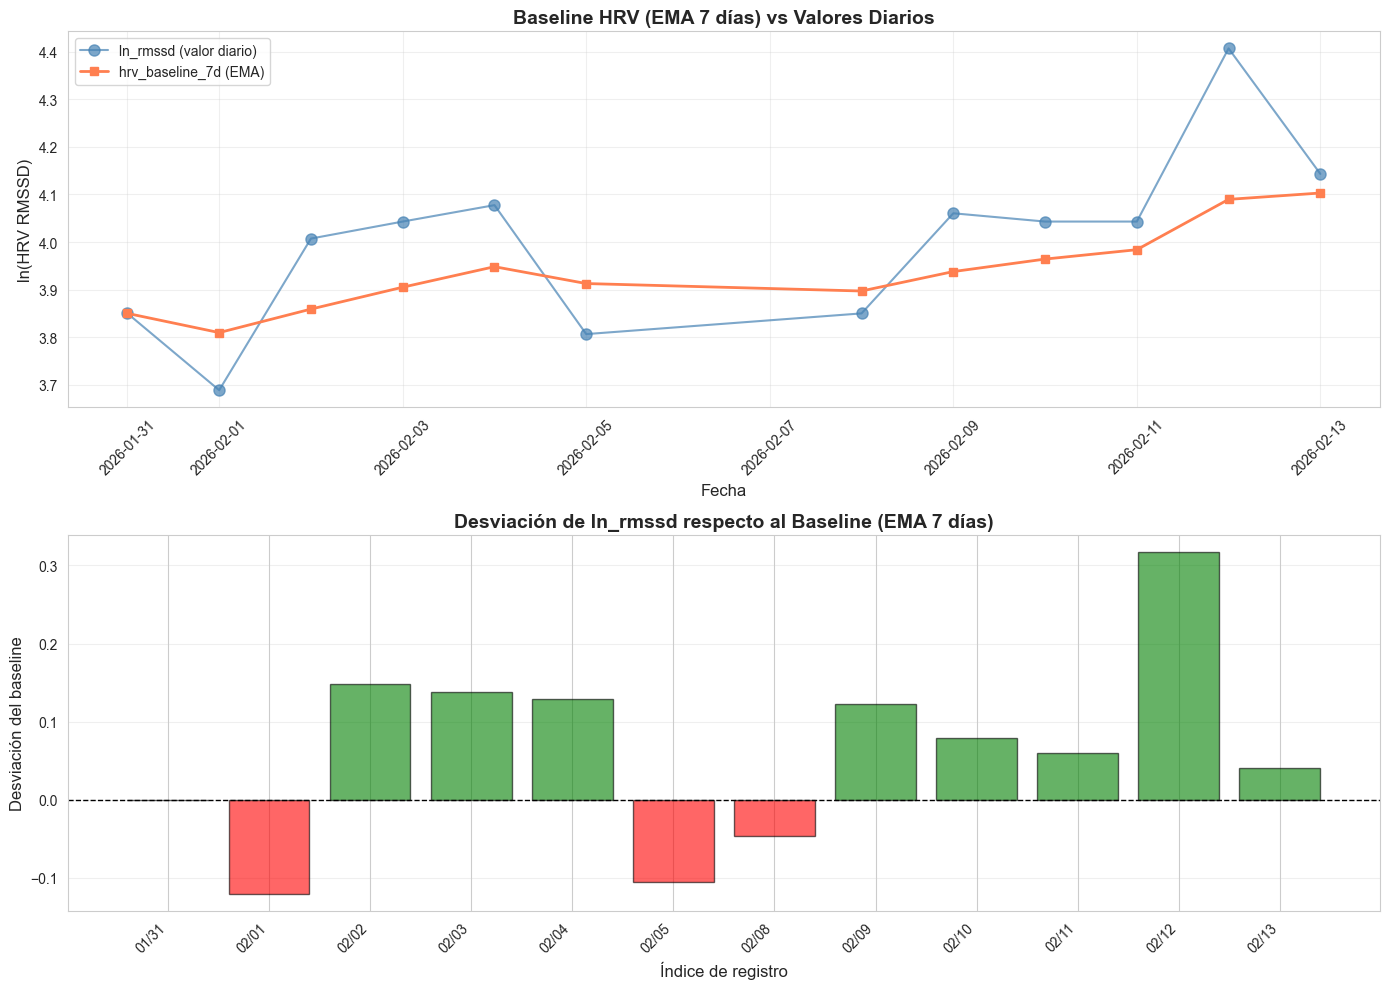


📊 Interpretación:
   • Valores por encima del baseline (verde) = mejor recuperación que tu normal
   • Valores por debajo del baseline (rojo) = peor recuperación que tu normal
   • El baseline se adapta gradualmente a cambios en tu condición física


In [23]:
# Visualización de baseline vs valores diarios
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: ln_rmssd vs baseline en el tiempo
ax1 = axes[0]
ax1.plot(df_hrv_sorted['date'], df_hrv_sorted['ln_rmssd'], 
         'o-', label='ln_rmssd (valor diario)', color='steelblue', alpha=0.7, markersize=8)
ax1.plot(df_hrv_sorted['date'], df_hrv_sorted['hrv_baseline_7d'], 
         's-', label='hrv_baseline_7d (EMA)', color='coral', linewidth=2, markersize=6)

ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('ln(HRV RMSSD)', fontsize=12)
ax1.set_title('Baseline HRV (EMA 7 días) vs Valores Diarios', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Desviación respecto al baseline
ax2 = axes[1]
colors = ['green' if x >= 0 else 'red' for x in df_hrv_sorted['deviation_from_baseline']]
ax2.bar(range(len(df_hrv_sorted)), df_hrv_sorted['deviation_from_baseline'], 
        color=colors, alpha=0.6, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Índice de registro', fontsize=12)
ax2.set_ylabel('Desviación del baseline', fontsize=12)
ax2.set_title('Desviación de ln_rmssd respecto al Baseline (EMA 7 días)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas de fecha en el eje x del segundo gráfico
ax2.set_xticks(range(len(df_hrv_sorted)))
ax2.set_xticklabels([d.strftime('%m/%d') for d in df_hrv_sorted['date']], rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("   • Valores por encima del baseline (verde) = mejor recuperación que tu normal")
print("   • Valores por debajo del baseline (rojo) = peor recuperación que tu normal")
print("   • El baseline se adapta gradualmente a cambios en tu condición física")

## 12. Resumen - Baseline HRV (hrv_baseline_7d)

El baseline calculado con EMA permite:

1. **Comparación relativa**: Saber si tu HRV de hoy está por encima o por debajo de tu "normal" personal
2. **Detección de tendencias**: Identificar mejoras o empeoramientos graduales en tu condición física
3. **Normalización para modelos**: Usar desviaciones del baseline como feature en lugar de valores absolutos
4. **Adaptabilidad**: El baseline se ajusta automáticamente a cambios en tu fitness sin necesidad de recalcular manualmente

---

# Parte 3: Consistencia del Sueño (sleep_consistency)

## 13. Concepto de Consistencia Circadiana

La **consistencia del sueño** mide qué tan regular es tu horario de dormir. Se calcula como la desviación estándar de la hora de dormir en una ventana móvil de 7 días.

**¿Por qué es importante?**

1. **Salud circadiana**: Horarios irregulares desincronizan tu reloj biológico interno
2. **Calidad del sueño**: La regularidad mejora la eficiencia del sueño y la recuperación
3. **Predictor de rendimiento**: La inconsistencia circadiana puede afectar el rendimiento cognitivo

**Fórmula**: 
```
sleep_consistency = std_dev(hora_dormir en últimos 7 días)
```

Valores más bajos = mayor consistencia (mejor)
Valores más altos = menor consistencia (peor)

In [24]:
# Convertir sleep_start_time a minutos desde medianoche para facilitar cálculos
def time_to_minutes(time_str: str) -> int:
    if pd.isna(time_str):
        return None
    try:
        hours, minutes = map(int, time_str.split(':'))
        return hours * 60 + minutes
    except:
        return None

# Aplicar conversión
df_hrv_sorted['sleep_start_minutes'] = df_hrv_sorted['sleep_start_time'].apply(time_to_minutes)

# Calcular desviación estándar móvil de 7 días
# Usar rolling window de 7 días
df_hrv_sorted['sleep_consistency'] = df_hrv_sorted['sleep_start_minutes'].rolling(
    window=7, min_periods=1
).std()

# Convertir de minutos a horas para interpretación más fácil
df_hrv_sorted['sleep_consistency_hours'] = df_hrv_sorted['sleep_consistency'] / 60

print("=== CÁLCULO DE CONSISTENCIA DEL SUEÑO ===\n")
print("Primeras filas con consistencia calculada:")
display_cols = ['date', 'sleep_start_time', 'sleep_start_minutes', 'sleep_consistency_hours']
print(df_hrv_sorted[display_cols].head(10))

print(f"\n📊 Estadísticas de consistencia del sueño:")
print(f"   • Media de consistencia: {df_hrv_sorted['sleep_consistency_hours'].mean():.2f} horas")
print(f"   • Desviación estándar: {df_hrv_sorted['sleep_consistency_hours'].std():.2f} horas")
print(f"   • Mínimo (más consistente): {df_hrv_sorted['sleep_consistency_hours'].min():.2f} horas")
print(f"   • Máximo (menos consistente): {df_hrv_sorted['sleep_consistency_hours'].max():.2f} horas")

# Interpretación
print(f"\n💡 Interpretación:")
print(f"   • Consistencia < 1 hora: Muy regular (excelente)")
print(f"   • Consistencia 1-2 horas: Regular (bueno)")
print(f"   • Consistencia > 2 horas: Irregular (mejorable)")

=== CÁLCULO DE CONSISTENCIA DEL SUEÑO ===

Primeras filas con consistencia calculada:
         date sleep_start_time  sleep_start_minutes  sleep_consistency_hours
0  2026-01-31            02:17                  137                      NaN
1  2026-02-01            02:37                  157                 0.235702
2  2026-02-02            22:51                 1371                11.779125
3  2026-02-03            23:07                 1387                11.856206
4  2026-02-04            23:54                 1434                11.421060
5  2026-02-05            23:33                 1413                10.801370
8  2026-02-08            01:51                  111                11.287611
9  2026-02-09            00:35                   35                11.603356
10 2026-02-10            02:18                  138                11.655934
11 2026-02-11            02:40                  160                11.604284

📊 Estadísticas de consistencia del sueño:
   • Media de consistenc

## 14. Visualización de Consistencia del Sueño

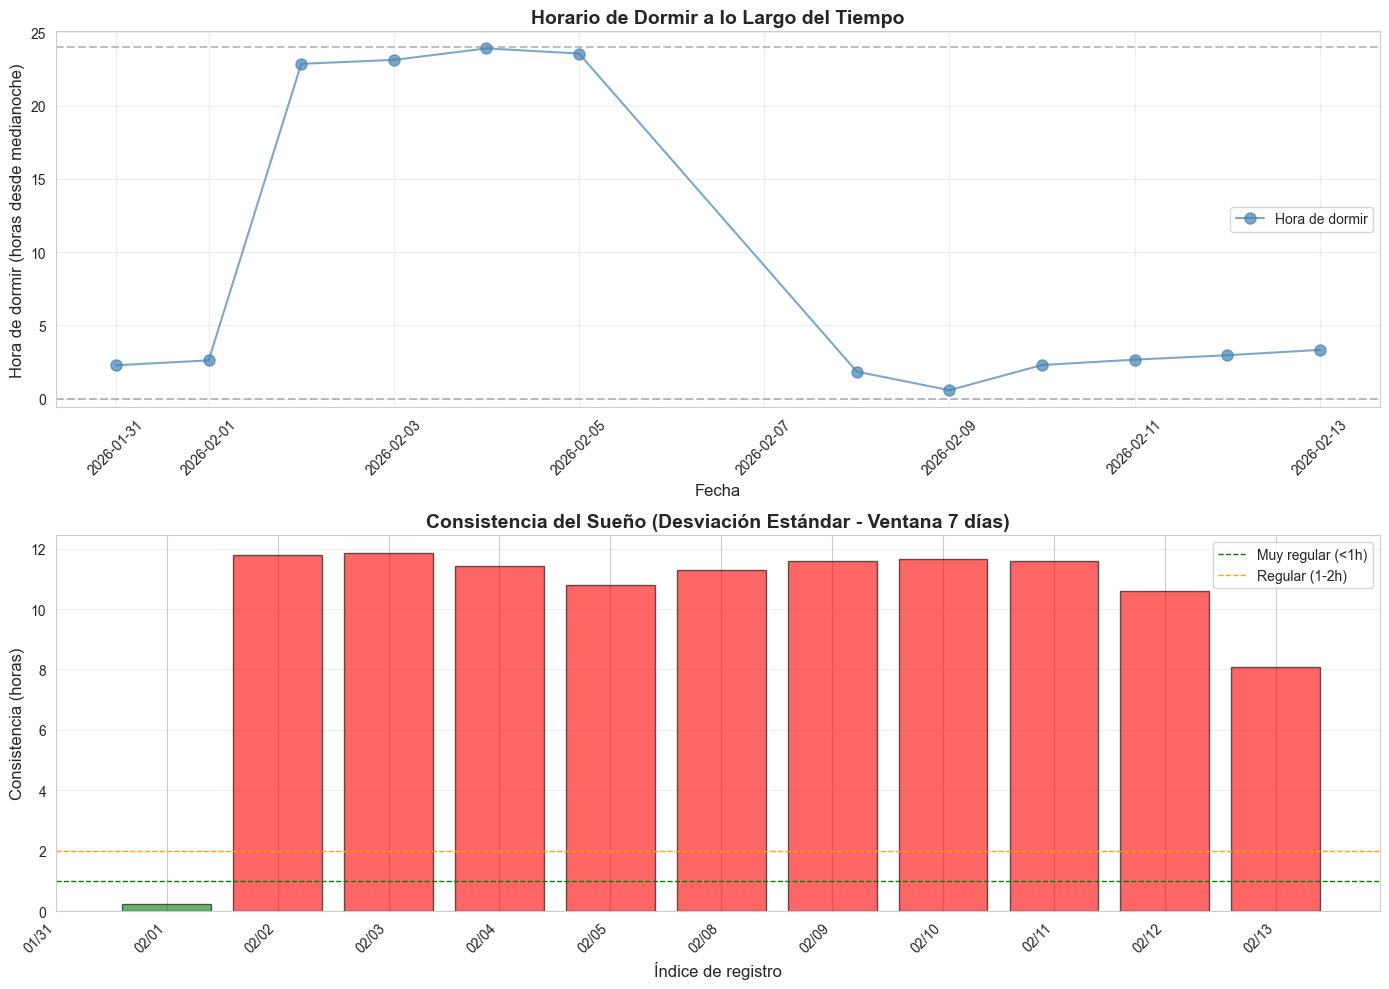


📊 Interpretación:
   • Verde (< 1h): Horario muy regular - excelente para salud circadiana
   • Naranja (1-2h): Horario regular - bueno
   • Rojo (> 2h): Horario irregular - puede afectar calidad del sueño


In [25]:
# Visualización de consistencia del sueño
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Hora de dormir en el tiempo
ax1 = axes[0]
# Convertir minutos a horas para visualización
sleep_hours = df_hrv_sorted['sleep_start_minutes'] / 60
ax1.plot(df_hrv_sorted['date'], sleep_hours, 
         'o-', label='Hora de dormir', color='steelblue', alpha=0.7, markersize=8)
ax1.set_xlabel('Fecha', fontsize=12)
ax1.set_ylabel('Hora de dormir (horas desde medianoche)', fontsize=12)
ax1.set_title('Horario de Dormir a lo Largo del Tiempo', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Añadir línea horizontal para referencia (medianoche = 0, medianoche siguiente = 24)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axhline(y=24, color='gray', linestyle='--', alpha=0.5)

# Gráfico 2: Consistencia del sueño (desviación estándar)
ax2 = axes[1]
colors_consistency = ['green' if x < 1 else 'orange' if x < 2 else 'red' 
                      for x in df_hrv_sorted['sleep_consistency_hours']]
ax2.bar(range(len(df_hrv_sorted)), df_hrv_sorted['sleep_consistency_hours'], 
        color=colors_consistency, alpha=0.6, edgecolor='black')
ax2.axhline(y=1, color='green', linestyle='--', linewidth=1, label='Muy regular (<1h)')
ax2.axhline(y=2, color='orange', linestyle='--', linewidth=1, label='Regular (1-2h)')
ax2.set_xlabel('Índice de registro', fontsize=12)
ax2.set_ylabel('Consistencia (horas)', fontsize=12)
ax2.set_title('Consistencia del Sueño (Desviación Estándar - Ventana 7 días)', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3, axis='y')

# Añadir etiquetas de fecha
ax2.set_xticks(range(len(df_hrv_sorted)))
ax2.set_xticklabels([d.strftime('%m/%d') for d in df_hrv_sorted['date']], rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n📊 Interpretación:")
print("   • Verde (< 1h): Horario muy regular - excelente para salud circadiana")
print("   • Naranja (1-2h): Horario regular - bueno")
print("   • Rojo (> 2h): Horario irregular - puede afectar calidad del sueño")

## 15. Correlación entre Consistencia del Sueño y Calidad del Sueño

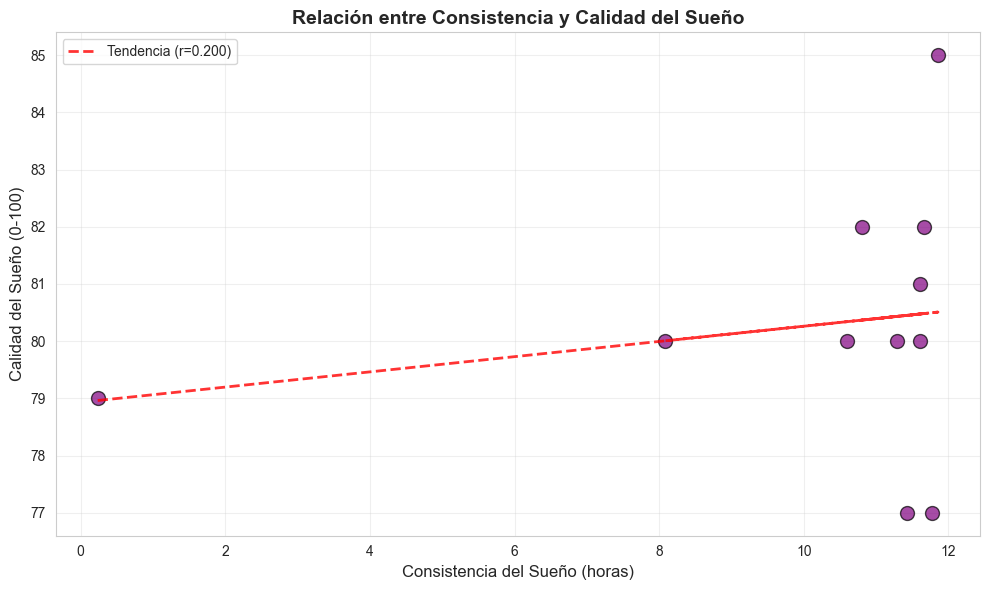


📊 Correlación entre consistencia y calidad del sueño:
   • Coeficiente de correlación: 0.200
   ℹ️  Correlación débil: La consistencia no explica mucho la calidad


In [26]:
# Filtrar datos válidos (donde tenemos ambos valores)
df_corr = df_hrv_sorted[
    df_hrv_sorted['sleep_consistency_hours'].notna() & 
    df_hrv_sorted['sleep_quality'].notna()
].copy()

if len(df_corr) > 1:
    # Calcular correlación
    correlation = df_corr['sleep_consistency_hours'].corr(df_corr['sleep_quality'])
    
    # Visualización
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.scatter(df_corr['sleep_consistency_hours'], df_corr['sleep_quality'], 
               alpha=0.7, s=100, color='purple', edgecolors='black')
    
    # Línea de regresión
    z = np.polyfit(df_corr['sleep_consistency_hours'], df_corr['sleep_quality'], 1)
    p = np.poly1d(z)
    ax.plot(df_corr['sleep_consistency_hours'], p(df_corr['sleep_consistency_hours']), 
            "r--", alpha=0.8, linewidth=2, label=f'Tendencia (r={correlation:.3f})')
    
    ax.set_xlabel('Consistencia del Sueño (horas)', fontsize=12)
    ax.set_ylabel('Calidad del Sueño (0-100)', fontsize=12)
    ax.set_title('Relación entre Consistencia y Calidad del Sueño', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📊 Correlación entre consistencia y calidad del sueño:")
    print(f"   • Coeficiente de correlación: {correlation:.3f}")
    
    if correlation < -0.3:
        print("   ✅ Correlación negativa moderada: Mayor consistencia → Mayor calidad")
    elif correlation > 0.3:
        print("   ⚠️  Correlación positiva: Mayor inconsistencia → Mayor calidad (contraintuitivo)")
    else:
        print("   ℹ️  Correlación débil: La consistencia no explica mucho la calidad")
else:
    print("⚠️  No hay suficientes datos para calcular correlación")

## 16. Resumen - Consistencia del Sueño (sleep_consistency)

La métrica de consistencia del sueño permite:

1. **Monitoreo de salud circadiana**: Identificar períodos de horarios irregulares
2. **Correlación con rendimiento**: Analizar si la regularidad afecta el rendimiento cognitivo
3. **Feature para modelos**: Usar como variable predictora en modelos de ML
4. **Feedback personal**: Identificar oportunidades de mejora en higiene del sueño

---

# Resumen Final: Las Tres Métricas Derivadas

## 17. Resumen General y Aplicación Práctica

In [27]:
print("=" * 80)
print("RESUMEN FINAL: TRES MÉTRICAS DERIVADAS PARA BIO-ADAPTABILIDAD")
print("=" * 80)

print("\n1️⃣  LN_RMSSD - Transformación Logarítmica HRV")
print("   • Propósito: Normalizar distribución log-normal a distribución gaussiana")
print("   • Fórmula: ln_rmssd = ln(hrv_rmssd)")
print("   • Beneficio: Facilita análisis estadísticos y modelos ML")
print(f"   • Valor promedio en datos: {df_hrv_sorted['ln_rmssd'].mean():.3f}")

print("\n2️⃣  HRV_BASELINE_7D - Media Móvil Exponencial")
print("   • Propósito: Establecer línea base personal adaptativa")
print("   • Fórmula: EMA(ln_rmssd, span=7)")
print("   • Beneficio: Comparación relativa y detección de tendencias")
print(f"   • Valor promedio en datos: {df_hrv_sorted['hrv_baseline_7d'].mean():.3f}")

print("\n3️⃣  SLEEP_CONSISTENCY - Regularidad Circadiana")
print("   • Propósito: Medir regularidad del horario de dormir")
print("   • Fórmula: std_dev(hora_dormir, ventana=7 días)")
print("   • Beneficio: Indicador de salud circadiana y predictor de rendimiento")
print(f"   • Valor promedio en datos: {df_hrv_sorted['sleep_consistency_hours'].mean():.2f} horas")

print("\n" + "=" * 80)
print("APLICACIÓN EN EL SISTEMA ICD (Índice Cognitivo Diario)")
print("=" * 80)
print("""
Estas métricas se utilizarán en el cálculo del ICD:

• ln_rmssd: Para normalización y cálculo de z-scores
• hrv_baseline_7d: Para comparar desviaciones respecto a tu "normal" personal
• sleep_consistency: Como feature adicional para predecir rendimiento cognitivo

Todas estas métricas deben calcularse automáticamente al insertar cada registro
en la base de datos DailyBiometrics.
""")

print("=" * 80)

RESUMEN FINAL: TRES MÉTRICAS DERIVADAS PARA BIO-ADAPTABILIDAD

1️⃣  LN_RMSSD - Transformación Logarítmica HRV
   • Propósito: Normalizar distribución log-normal a distribución gaussiana
   • Fórmula: ln_rmssd = ln(hrv_rmssd)
   • Beneficio: Facilita análisis estadísticos y modelos ML
   • Valor promedio en datos: 4.002

2️⃣  HRV_BASELINE_7D - Media Móvil Exponencial
   • Propósito: Establecer línea base personal adaptativa
   • Fórmula: EMA(ln_rmssd, span=7)
   • Beneficio: Comparación relativa y detección de tendencias
   • Valor promedio en datos: 3.938

3️⃣  SLEEP_CONSISTENCY - Regularidad Circadiana
   • Propósito: Medir regularidad del horario de dormir
   • Fórmula: std_dev(hora_dormir, ventana=7 días)
   • Beneficio: Indicador de salud circadiana y predictor de rendimiento
   • Valor promedio en datos: 10.08 horas

APLICACIÓN EN EL SISTEMA ICD (Índice Cognitivo Diario)

Estas métricas se utilizarán en el cálculo del ICD:

• ln_rmssd: Para normalización y cálculo de z-scores
• hr

## 18. Exportación de Resultados

In [ ]:
# Guardar DataFrame con todas las métricas derivadas calculadas
output_path = Path("../../data/biometrics/suunto_data_with_derived_metrics.csv")
df_hrv_sorted.to_csv(output_path, index=False)

print(f"✅ Datos exportados a: {output_path}")
print(f"\nColumnas en el archivo exportado:")
print(df_hrv_sorted.columns.tolist())

# Mostrar muestra de datos con todas las métricas derivadas
print("\n📋 Muestra de datos con todas las métricas derivadas:")
display_cols_final = ['date', 'hrv_rmssd', 'ln_rmssd', 'hrv_baseline_7d', 
                       'sleep_start_time', 'sleep_consistency_hours']
print(df_hrv_sorted[display_cols_final].head(10))

print("\n✅ Las tres métricas derivadas están calculadas y listas para usar en el sistema ICD:")
print("   1. ln_rmssd: Transformación logarítmica")
print("   2. hrv_baseline_7d: Baseline con EMA 7 días")
print("   3. sleep_consistency: Regularidad circadiana (en horas)")

## 6. Visualizaciones Comparativas

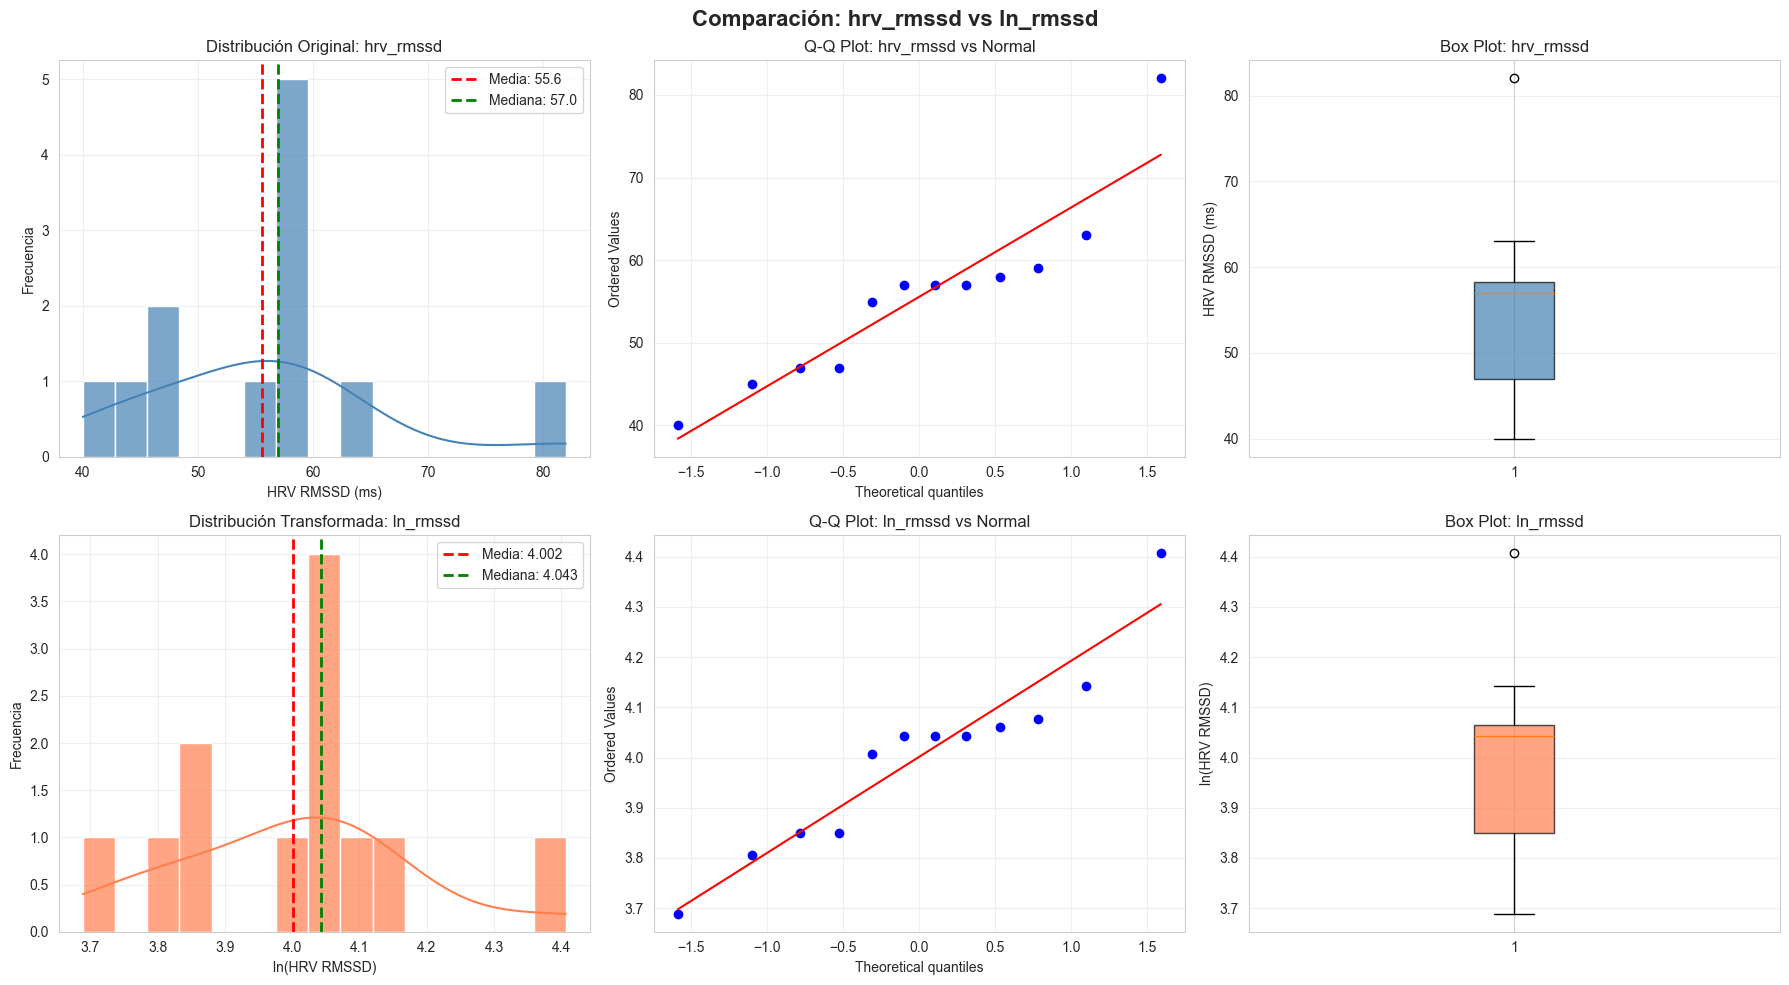

In [12]:
# Crear figura con subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparación: hrv_rmssd vs ln_rmssd', fontsize=16, fontweight='bold')

# === FILA 1: Distribución Original (hrv_rmssd) ===

# Histograma + KDE
ax1 = axes[0, 0]
sns.histplot(hrv_values, kde=True, bins=15, ax=ax1, color='steelblue', alpha=0.7)
ax1.axvline(hrv_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {hrv_values.mean():.1f}')
ax1.axvline(np.median(hrv_values), color='green', linestyle='--', linewidth=2, label=f'Mediana: {np.median(hrv_values):.1f}')
ax1.set_xlabel('HRV RMSSD (ms)')
ax1.set_ylabel('Frecuencia')
ax1.set_title('Distribución Original: hrv_rmssd')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Q-Q Plot
ax2 = axes[0, 1]
stats.probplot(hrv_values, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: hrv_rmssd vs Normal')
ax2.grid(True, alpha=0.3)

# Box Plot
ax3 = axes[0, 2]
ax3.boxplot(hrv_values, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
ax3.set_ylabel('HRV RMSSD (ms)')
ax3.set_title('Box Plot: hrv_rmssd')
ax3.grid(True, alpha=0.3, axis='y')

# === FILA 2: Distribución Transformada (ln_rmssd) ===

# Histograma + KDE
ax4 = axes[1, 0]
sns.histplot(ln_values, kde=True, bins=15, ax=ax4, color='coral', alpha=0.7)
ax4.axvline(ln_values.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {ln_values.mean():.3f}')
ax4.axvline(np.median(ln_values), color='green', linestyle='--', linewidth=2, label=f'Mediana: {np.median(ln_values):.3f}')
ax4.set_xlabel('ln(HRV RMSSD)')
ax4.set_ylabel('Frecuencia')
ax4.set_title('Distribución Transformada: ln_rmssd')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Q-Q Plot
ax5 = axes[1, 1]
stats.probplot(ln_values, dist="norm", plot=ax5)
ax5.set_title('Q-Q Plot: ln_rmssd vs Normal')
ax5.grid(True, alpha=0.3)

# Box Plot
ax6 = axes[1, 2]
ax6.boxplot(ln_values, vert=True, patch_artist=True,
            boxprops=dict(facecolor='coral', alpha=0.7))
ax6.set_ylabel('ln(HRV RMSSD)')
ax6.set_title('Box Plot: ln_rmssd')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Visualización Comparativa Lado a Lado

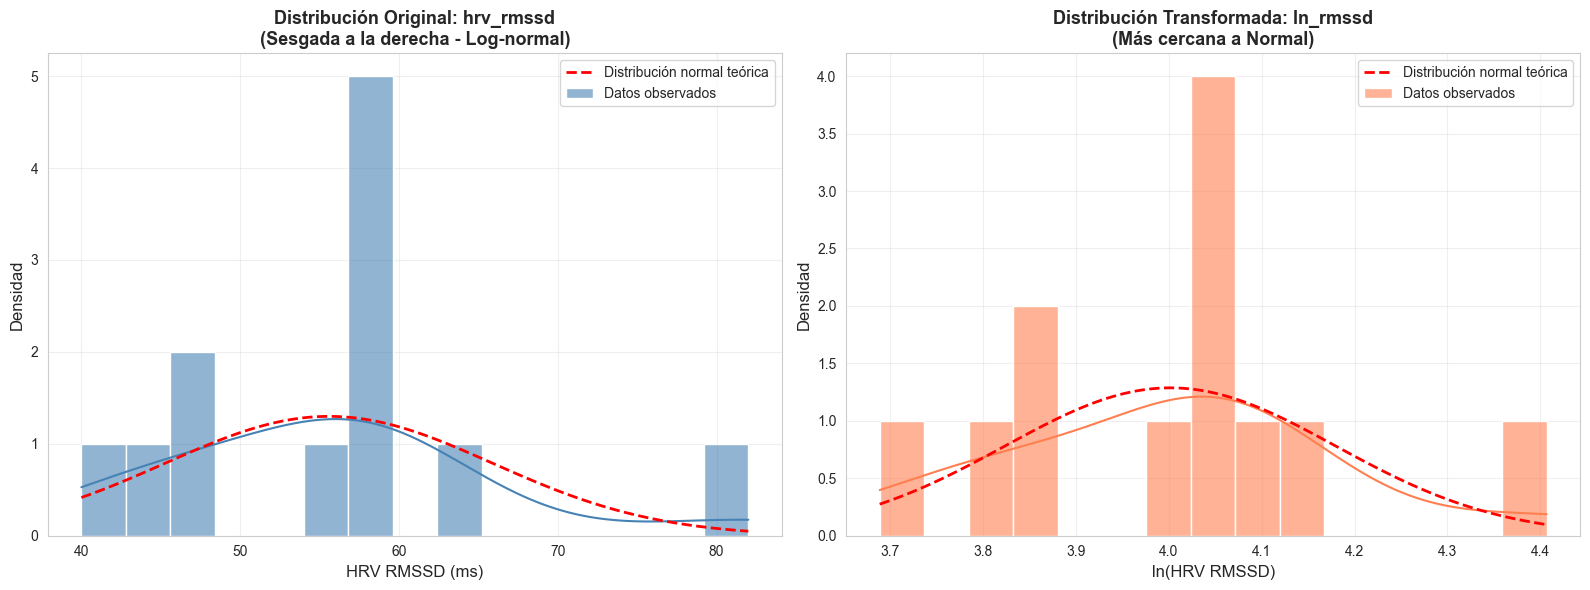

In [13]:
# Comparación directa: histogramas superpuestos con curvas normales teóricas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución original
ax1 = axes[0]
sns.histplot(hrv_values, kde=True, bins=15, ax=ax1, color='steelblue', alpha=0.6, label='Datos observados')

# Curva normal teórica con misma media y desviación estándar
x_norm_orig = np.linspace(hrv_values.min(), hrv_values.max(), 100)
y_norm_orig = stats.norm.pdf(x_norm_orig, hrv_values.mean(), hrv_values.std())
# Escalar para que coincida con el histograma
y_norm_orig_scaled = y_norm_orig * len(hrv_values) * (hrv_values.max() - hrv_values.min()) / 15
ax1.plot(x_norm_orig, y_norm_orig_scaled, 'r--', linewidth=2, label='Distribución normal teórica')

ax1.set_xlabel('HRV RMSSD (ms)', fontsize=12)
ax1.set_ylabel('Densidad', fontsize=12)
ax1.set_title('Distribución Original: hrv_rmssd\n(Sesgada a la derecha - Log-normal)', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribución transformada
ax2 = axes[1]
sns.histplot(ln_values, kde=True, bins=15, ax=ax2, color='coral', alpha=0.6, label='Datos observados')

# Curva normal teórica
x_norm_trans = np.linspace(ln_values.min(), ln_values.max(), 100)
y_norm_trans = stats.norm.pdf(x_norm_trans, ln_values.mean(), ln_values.std())
# Escalar para que coincida con el histograma
y_norm_trans_scaled = y_norm_trans * len(ln_values) * (ln_values.max() - ln_values.min()) / 15
ax2.plot(x_norm_trans, y_norm_trans_scaled, 'r--', linewidth=2, label='Distribución normal teórica')

ax2.set_xlabel('ln(HRV RMSSD)', fontsize=12)
ax2.set_ylabel('Densidad', fontsize=12)
ax2.set_title('Distribución Transformada: ln_rmssd\n(Más cercana a Normal)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Análisis de Relación Lineal

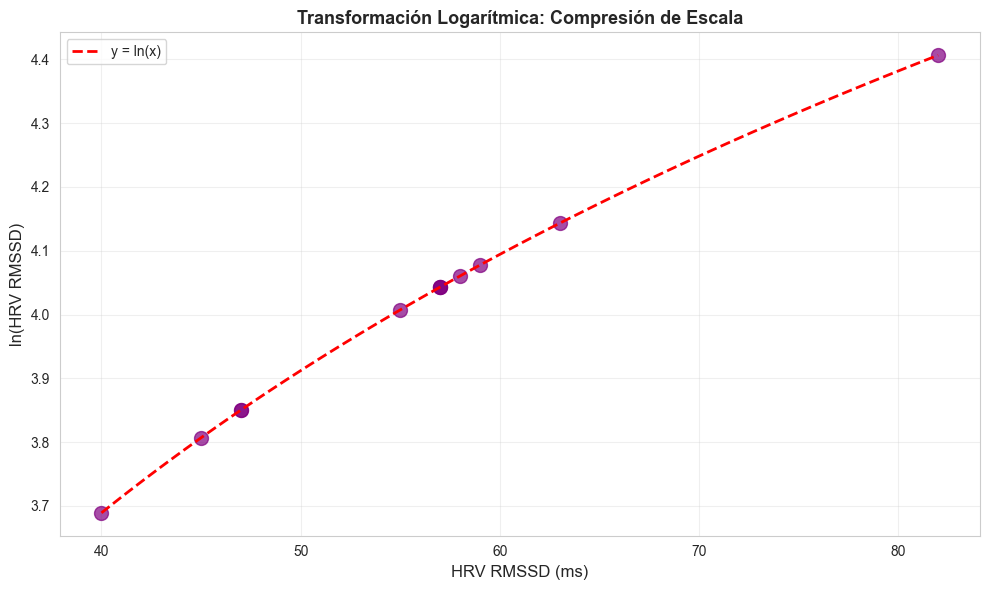


📊 Observación:
La transformación logarítmica comprime los valores altos más que los bajos.
Esto estabiliza la varianza y hace que la distribución sea más simétrica.


In [14]:
# Scatter plot mostrando la relación entre valores originales y transformados
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df_hrv['hrv_rmssd'], df_hrv['ln_rmssd'], alpha=0.7, s=100, color='purple')

# Línea teórica: y = ln(x)
x_line = np.linspace(df_hrv['hrv_rmssd'].min(), df_hrv['hrv_rmssd'].max(), 100)
y_line = np.log(x_line)
ax.plot(x_line, y_line, 'r--', linewidth=2, label='y = ln(x)')

ax.set_xlabel('HRV RMSSD (ms)', fontsize=12)
ax.set_ylabel('ln(HRV RMSSD)', fontsize=12)
ax.set_title('Transformación Logarítmica: Compresión de Escala', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Observación:")
print("La transformación logarítmica comprime los valores altos más que los bajos.")
print("Esto estabiliza la varianza y hace que la distribución sea más simétrica.")

## 9. Resumen y Conclusiones

In [15]:
print("=" * 70)
print("RESUMEN DEL ESTUDIO: Transformación Logarítmica HRV")
print("=" * 70)

print("\n📈 DISTRIBUCIÓN ORIGINAL (hrv_rmssd):")
print(f"   • Media: {hrv_values.mean():.2f} ms")
print(f"   • Mediana: {np.median(hrv_values):.2f} ms")
print(f"   • Desviación estándar: {hrv_values.std():.2f} ms")
print(f"   • Asimetría: {stats.skew(hrv_values):.3f} {'(sesgada a la derecha)' if stats.skew(hrv_values) > 0 else ''}")

print("\n📊 DISTRIBUCIÓN TRANSFORMADA (ln_rmssd):")
print(f"   • Media: {ln_values.mean():.3f}")
print(f"   • Mediana: {np.median(ln_values):.3f}")
print(f"   • Desviación estándar: {ln_values.std():.3f}")
print(f"   • Asimetría: {stats.skew(ln_values):.3f} {'(más simétrica)' if abs(stats.skew(ln_values)) < abs(stats.skew(hrv_values)) else ''}")

print("\n✅ BENEFICIOS DE LA TRANSFORMACIÓN:")
print("   1. Reducción de asimetría: Distribución más simétrica")
print("   2. Estabilización de varianza: Mejor para modelos estadísticos")
print("   3. Normalización: Más cercana a distribución gaussiana")
print("   4. Compresión de outliers: Reduce impacto de valores extremos")

print("\n🎯 APLICACIÓN PRÁCTICA:")
print("   • Usar ln_rmssd en modelos de regresión y Machine Learning")
print("   • Facilita el cálculo de z-scores para comparación con baseline")
print("   • Mejora la interpretabilidad en análisis de correlación")
print("   • Permite usar tests estadísticos que asumen normalidad")

print("\n" + "=" * 70)

RESUMEN DEL ESTUDIO: Transformación Logarítmica HRV

📈 DISTRIBUCIÓN ORIGINAL (hrv_rmssd):
   • Media: 55.58 ms
   • Mediana: 57.00 ms
   • Desviación estándar: 10.32 ms
   • Asimetría: 0.960 (sesgada a la derecha)

📊 DISTRIBUCIÓN TRANSFORMADA (ln_rmssd):
   • Media: 4.002
   • Mediana: 4.043
   • Desviación estándar: 0.178
   • Asimetría: 0.372 (más simétrica)

✅ BENEFICIOS DE LA TRANSFORMACIÓN:
   1. Reducción de asimetría: Distribución más simétrica
   2. Estabilización de varianza: Mejor para modelos estadísticos
   3. Normalización: Más cercana a distribución gaussiana
   4. Compresión de outliers: Reduce impacto de valores extremos

🎯 APLICACIÓN PRÁCTICA:
   • Usar ln_rmssd en modelos de regresión y Machine Learning
   • Facilita el cálculo de z-scores para comparación con baseline
   • Mejora la interpretabilidad en análisis de correlación
   • Permite usar tests estadísticos que asumen normalidad



## 10. Exportación de Resultados

In [ ]:
# Guardar DataFrame con la transformación aplicada
output_path = Path("../../data/biometrics/suunto_data_with_ln_rmssd.csv")
df_hrv.to_csv(output_path, index=False)

print(f"✅ Datos exportados a: {output_path}")
print(f"\nColumnas en el archivo exportado:")
print(df_hrv.columns.tolist())

# Mostrar muestra de datos transformados
print("\n📋 Muestra de datos con transformación aplicada:")
df_hrv[['date', 'hrv_rmssd', 'ln_rmssd']].head(10)